# Getting cutouts straight from the Zooniverse `.csv` export
The JSON files from Sophie's paper contain aggregated data from ~20000 volunteers.

We want to get at the "raw" box data. So we do that here.

A UMN researcher (Lestat) exported the Zooniverse "box the jet" information from the website to [a CSV file](https://drive.google.com/file/d/16A91wIPhhaEGvMGp0hrOeVNCsu-vwvVY/view?usp=sharing).
It contains information on the images which were boxed so that the bounding boxes can be converted from image to physical coordinates.
It was exported using `bash`:
```bash
# First, install the Zooniverse panoptes package
$(which uv) pip install panoptescli

# Configure it with username/password which has access to the SJH project
panoptes configure

# Finally, download the "box the jet" workflow to a CSV
panoptes workflow download-classifications 21225 box-the-jets.csv
# Optionally regenerate the workflow data set if required by adding the -g option
# panoptes workflow download-classifications -g 21225 box-the-jets.csv
```

There is also additional information regarding the "base" of each jet.
We don't care about the bases of the jets, just the bounding boxes, so we can ignore that.

In [1]:
import astropy.units as u
import astropy.coordinates as acoord
import regions

import zooniverse_processing as zp

In [2]:
# For the first version of the project, v4.52 looks like the "production" version
cutoff_version = 4.52
extracted = zp.load_zooniverse_csv("box-the-jets-first-version.csv", cutoff_version=cutoff_version)

In [3]:
# Grab a specific Zooniverse subject ID to look at
test_id = 70444527
zooniverse_pair = extracted[test_id]

meta_ = extracted[test_id].meta
# The metadata is the same for each subject ID even if it's visited by
# multiple volunteers
bounding_boxes = extracted[test_id].bounding_boxes
meta_

{'fits_header': {'naxis1': 639.0,
  'naxis2': 740.0,
  'cunit1': 'arcsec',
  'cunit2': 'arcsec',
  'crval1': 0.0,
  'crval2': 0.0,
  'cdelt1': 0.600165,
  'cdelt2': 0.600165,
  'crpix1': 2060.77002,
  'crpix2': 18.040039,
  'crota2': -0.131644},
 'image_extract_data': {'lower_left_x_prop': 0.263160472972973,
  'lower_left_y_prop': 0.10999999999999999,
  'upper_right_x_prop': 0.7618395270270271,
  'upper_right_y_prop': 0.88,
  'width': 1920.0,
  'height': 1440.0},
 'frame_filenames': ['ssw_cutout_20121217_093455_aia_304_36786.png',
  'ssw_cutout_20121217_093531_aia_304_36787.png',
  'ssw_cutout_20121217_093607_aia_304_36788.png',
  'ssw_cutout_20121217_093643_aia_304_36789.png',
  'ssw_cutout_20121217_093719_aia_304_36790.png',
  'ssw_cutout_20121217_093755_aia_304_36791.png',
  'ssw_cutout_20121217_093831_aia_304_36792.png',
  'ssw_cutout_20121217_093907_aia_304_36793.png',
  'ssw_cutout_20121217_093943_aia_304_36794.png',
  'ssw_cutout_20121217_094019_aia_304_36795.png',
  'ssw_cutout

In [4]:
import pathlib
box_files = zp.reassociate_bounding_boxes(meta_, bounding_boxes, root_path=pathlib.Path("."), epsilon=(40 << u.s))

In [5]:
# Check that each file is associated with a box
len(box_files), len(bounding_boxes)

(14, 14)

In [6]:
# Test getting a sky region from the Zooniverse data
jet_regions = tuple(
    zp.sky_region_from_zooniverse_rect(box=b, meta=meta_) for b in bounding_boxes
)

In [7]:
# Get a region that encompasses all the boxes
(lower_left, upper_right) = zooniverse_pair.bounding_corners_from_boxes()
width, height = (upper_right - lower_left)

/home/william/grad_school/glesener/analysis/jethunter/helioml-jets/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/william/grad_school/glesener/analysis/jethunter/helioml-jets/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/william/grad_school/glesener/analysis/jethunter/helioml-jets/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/william/grad_school/glesener/analysis/jethunter/helioml-jets/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2625: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/william/grad_school/gl

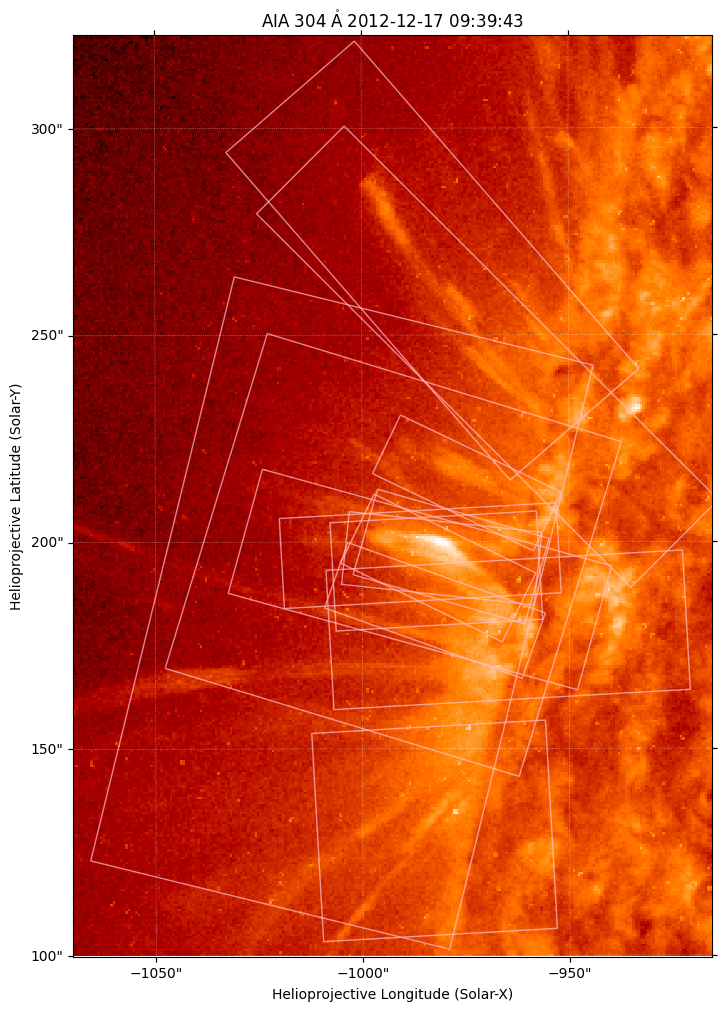

In [8]:
import sunpy.map as smap
from sunpy.map.sources import sdo
from sunpy.coordinates import SphericalScreen
import matplotlib.pyplot as plt
import astropy.coordinates as acoord

%matplotlib inline

file_idx = 3
fn = box_files[file_idx]
m: sdo.AIAMap = smap.Map(fn)
m = m.submap(
    bottom_left=acoord.SkyCoord(*lower_left, frame=m.coordinate_frame),
    width=width,
    height=height
)
# Cut out only the region we care about
fig, ax = plt.subplots(subplot_kw={"projection": m.wcs}, layout="constrained", figsize=(10, 10))
m.plot(axes=ax)

with SphericalScreen(center=m.observer_coordinate):
    map_time = m.observer_coordinate.obstime
    for i, jet_region in enumerate(jet_regions):
        px = jet_region.to_pixel(wcs=m.wcs)
        px.plot(ax=ax, color="pink", alpha=0.7)

# ax.set(xlim=(lower_left[0], upper_right[0]), ylim=(lower_left[1], upper_right[1]))
plt.show()